# P03 — Probability, Statistics & Information Theory  *(learning to live with doubt)*

> **The story so far.** The mind can sense ([P01](P01_Linear_Algebra.ipynb)) and it has the urge to
> improve ([P02](P02_Calculus_and_Gradients.ipynb)) — it knows how to walk downhill. But it has been
> living in a tidy world of exact numbers, and the real world isn't tidy. A weather app doesn't say
> "it will rain"; it says "70% chance." A good doctor doesn't say "you're sick"; she weighs the
> odds. Today the mind grows up a little and **learns to live with doubt** — to hold many possible
> answers at once and say how strongly it believes each. And out of this comes the single most
> important quantity in its whole life: **cross-entropy**, the exact measure of wrongness a language
> model spends every training step trying to shrink. By the end you'll have derived it by hand.

A language model never says "the next word IS *cat*." It says "*cat* with probability 0.66, *sat*
0.24, *mat* 0.09." To build, train, and reason about such a model you need the vocabulary of
**uncertainty**: probabilities, expectation, variance, Bayes' rule — and then **information theory**
(entropy, cross-entropy, KL divergence), which gives the precise number a model is trained to make
small. By the end you will have *derived* cross-entropy by hand and matched PyTorch's value.

As always: plain words → tiny worked example by hand → code that verifies. We lean on
[P00](P00_Python_and_NumPy_for_ML.ipynb) (arrays, sums) and [P02](P02_Calculus_and_Gradients.ipynb)
(logs appear here; we treat `ln` as a given function).

## B1 — A probability distribution: non-negative numbers that sum to 1

Tomorrow's forecast splits the day's belief into slices: 70% rain, 20% cloud, 10% sun. You can't
have a *negative* 30% chance of rain, and the slices must cover the whole pie — something happens
tomorrow. That pie of belief, sliced so the pieces are never negative and always add to one whole,
is a **probability distribution**. It's exactly the shape the mind's output takes when it guesses
the next word.

A **distribution** assigns each possible outcome a probability. Two iron rules: every probability
is `≥ 0`, and they **sum to exactly 1** (something must happen). This is precisely the shape
softmax produces (Notebook 00, B6).

**Worked example by hand.** A loaded die over 3 outcomes `{A, B, C}` with `p = [0.5, 0.3, 0.2]`:
```
all ≥ 0 ?  yes
sum = 0.5 + 0.3 + 0.2 = 1.0 ?  yes  -> valid distribution
P(A or B) = 0.5 + 0.3 = 0.8   (probabilities of distinct outcomes add)
```

In [1]:
import numpy as np
p = np.array([0.5, 0.3, 0.2])
print("p           :", p)
print("all >= 0    :", bool((p >= 0).all()))
print("sum to 1    :", p.sum())
print("P(A or B)   :", p[0] + p[1], " (hand 0.8)")
print("\nan INVALID 'distribution' [0.5, 0.7] sums to", np.array([0.5,0.7]).sum(), "-> not allowed")

p           : [0.5 0.3 0.2]
all >= 0    : True
sum to 1    : 1.0
P(A or B)   : 0.8  (hand 0.8)

an INVALID 'distribution' [0.5, 0.7] sums to 1.2 -> not allowed


## B2 — Expectation (mean) and variance (spread)

A casino doesn't sweat any single spin of the wheel; it knows the *average* payout per spin over a
long night, and how wildly the takings swing around that average. The first number — the long-run
average — is the **expectation**. The second — how much the results scatter — is the **variance**.
The mind needs both: expectation is how we average loss over a whole dataset, and variance governs
how it initializes and normalizes its weights later.

The **expectation** `E[X]` is the long-run average: each value times its probability, summed. The
**variance** measures how spread out the values are: the average squared distance from the mean.

**Formulas:**  `E[X] = Σ pᵢ·xᵢ`   and   `Var[X] = Σ pᵢ·(xᵢ − E[X])²`

**Worked example by hand.** Values `x = [1, 2, 3]` with `p = [0.5, 0.3, 0.2]`:
```
E[X]   = 0.5·1 + 0.3·2 + 0.2·3 = 0.5 + 0.6 + 0.6 = 1.7
Var[X] = 0.5·(1−1.7)² + 0.3·(2−1.7)² + 0.2·(3−1.7)²
       = 0.5·0.49 + 0.3·0.09 + 0.2·1.69
       = 0.245 + 0.027 + 0.338 = 0.610
```
Expectation underlies *every* loss (we average loss over data) and the reward in RLHF (P24).

In [2]:
import numpy as np
x = np.array([1.0, 2.0, 3.0])
p = np.array([0.5, 0.3, 0.2])

E  = (p * x).sum()
Var = (p * (x - E)**2).sum()
print("E[X]   =", E,   " (hand 1.7)")
print("Var[X] =", round(Var, 3), " (hand 0.610)")
print("std    =", round(np.sqrt(Var), 3), " (sqrt of variance)")

E[X]   = 1.7000000000000002  (hand 1.7)
Var[X] = 0.61  (hand 0.610)
std    = 0.781  (sqrt of variance)


## B3 — Conditional probability & Bayes' rule: updating belief with evidence

Your phone buzzes with a fraud alert: a card was just used two countries away. How worried should
you be? It depends not only on how suspicious that *looks*, but on how rare fraud is to begin with.
Updating a belief in the light of fresh evidence — without forgetting how unusual the thing was in
the first place — is **Bayes' rule**, the mind's way of changing its mind for the right reasons.

`P(A | B)` reads "probability of A **given that** B happened." **Bayes' rule** flips a conditional
around — it's how you update a belief after seeing evidence, and it underpins Naive Bayes (P09) and
the whole probabilistic view of learning.

**Formula:**  `P(A | B) = P(B | A) · P(A) / P(B)`

**Worked example by hand — a classic medical test.** A disease affects 1% of people. A test is 90%
accurate for sick people (`P(+|sick)=0.9`) and has a 5% false-positive rate (`P(+|well)=0.05`). You
test positive — what's the chance you're actually sick?
```
P(sick)=0.01,  P(well)=0.99
P(+) = P(+|sick)P(sick) + P(+|well)P(well) = 0.9·0.01 + 0.05·0.99 = 0.009 + 0.0495 = 0.0585
P(sick|+) = P(+|sick)·P(sick) / P(+) = 0.009 / 0.0585 = 0.1538...
```
Only ~15%! The rarity of the disease (the **prior**) dominates. This counter-intuitive result is
why Bayesian reasoning matters.

In [3]:
p_sick = 0.01
p_pos_given_sick = 0.90
p_pos_given_well = 0.05

p_well = 1 - p_sick
p_pos  = p_pos_given_sick*p_sick + p_pos_given_well*p_well        # total prob of testing +
p_sick_given_pos = p_pos_given_sick*p_sick / p_pos               # Bayes

print("P(+) overall       =", round(p_pos, 4),            " (hand 0.0585)")
print("P(sick | +)        =", round(p_sick_given_pos, 4), " (hand 0.1538)")
print("-> a positive test means only ~15% chance of being sick, because the disease is rare.")

P(+) overall       = 0.0585  (hand 0.0585)
P(sick | +)        = 0.1538  (hand 0.1538)
-> a positive test means only ~15% chance of being sick, because the disease is rare.


## B4 — Entropy: how much uncertainty is in a distribution

"The sun rose this morning" carries no news — you knew it would. "A meteor landed in the park"
carries a lot — you never saw it coming. Surprise is high exactly when an outcome was unlikely, and
the *average* surprise of a whole distribution is its **entropy**: near zero when one outcome is a
near-certainty, large when every outcome is equally up-for-grabs. This is the conceptual root of the
loss the mind will be trained on.

**Entropy** `H(p)` measures uncertainty in bits/nats — how *surprised* you are on average. A sure
thing has entropy 0; a uniform coin flip is maximally uncertain. We use natural log (`ln`), giving
"nats" (matches PyTorch).

**Formula:**  `H(p) = − Σ pᵢ · ln(pᵢ)`

**Worked example by hand.**
```
certain  p=[1, 0]:        H = −(1·ln1 + 0·…) = −(0 + 0) = 0       (no surprise)
fair coin p=[0.5, 0.5]:   H = −(0.5·ln0.5 + 0.5·ln0.5)
                            = −(0.5·(−0.693) + 0.5·(−0.693)) = 0.693 nats  (max for 2 outcomes)
skewed   p=[0.9, 0.1]:    H = −(0.9·ln0.9 + 0.1·ln0.1)
                            = −(0.9·(−0.105) + 0.1·(−2.303)) = −(−0.0948 − 0.2303) = 0.325
```
Less predictable → higher entropy. This is the conceptual root of the loss we build next.

In [4]:
import numpy as np
def entropy(p):
    p = np.array(p, dtype=float)
    return -np.sum([pi*np.log(pi) for pi in p if pi > 0])        # skip 0 (0·ln0 := 0)

print("H([1, 0])      =", round(entropy([1, 0]), 3),     " (hand 0.000 — certain)")
print("H([0.5, 0.5])  =", round(entropy([0.5, 0.5]), 3), " (hand 0.693 — max for 2 outcomes)")
print("H([0.9, 0.1])  =", round(entropy([0.9, 0.1]), 3), " (hand 0.325)")
print("H([1/3,1/3,1/3])=", round(entropy([1/3,1/3,1/3]),3)," (uniform over 3 = ln 3 = 1.099)")

H([1, 0])      = -0.0  (hand 0.000 — certain)
H([0.5, 0.5])  = 0.693  (hand 0.693 — max for 2 outcomes)
H([0.9, 0.1])  = 0.325  (hand 0.325)
H([1/3,1/3,1/3])= 1.099  (uniform over 3 = ln 3 = 1.099)


### 📊 Step 4 — See it & play with it: entropy = how spread-out (uncertain) a distribution is

The bars show a 3-outcome distribution; the title shows its entropy. Drag the bars and watch:
entropy is **highest when the bars are equal** (maximally uncertain — you can't predict the outcome)
and **drops toward 0 as one bar dominates** (nearly certain — no surprise). This is the exact
quantity a model's loss is built from.

**▶ Run the cell and drag the sliders** (they auto-normalise to sum to 1):
1. Make all three roughly equal — entropy peaks near `ln 3 ≈ 1.10`.
2. Push one bar to ~1.0 and the others to ~0 — entropy collapses toward 0.

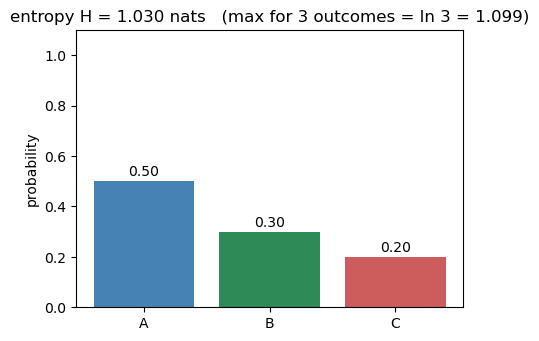

interactive(children=(FloatSlider(value=0.5, description='A', max=1.0, min=0.01, step=0.05), FloatSlider(value…

In [5]:
import numpy as np, matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def show_entropy(p0=0.5, p1=0.3, p2=0.2):
    p = np.array([p0, p1, p2], float)
    p = p / p.sum()                                         # normalise to a valid distribution
    H = -np.sum([pi*np.log(pi) for pi in p if pi > 0])
    fig, ax = plt.subplots(figsize=(5, 3.6))
    bars = ax.bar(["A","B","C"], p, color=["steelblue","seagreen","indianred"])
    for b, pi in zip(bars, p): ax.text(b.get_x()+b.get_width()/2, pi+0.02, f"{pi:.2f}", ha="center")
    ax.set_ylim(0, 1.1); ax.set_ylabel("probability")
    ax.set_title(f"entropy H = {H:.3f} nats   (max for 3 outcomes = ln 3 = 1.099)")
    plt.show()

show_entropy()                                              # static picture (always visible)
interact(show_entropy,                                      # ▶ live sliders (drag them in your IDE)
         p0=FloatSlider(min=0.01, max=1, step=0.05, value=0.5, description="A"),
         p1=FloatSlider(min=0.01, max=1, step=0.05, value=0.3, description="B"),
         p2=FloatSlider(min=0.01, max=1, step=0.05, value=0.2, description="C"));

## B5 — Cross-entropy: the loss a language model actually minimises

Here is the payoff — the most important formula in the mind's whole life. Picture the mind taking a
fill-in-the-blank exam: the true answer is "cat," and it must declare how confident it is. If it
says "cat: 99%" it pays almost nothing; if it confidently says "mat: 95%" it pays dearly. The grade
for that single guess — how badly its declared probabilities missed the truth — is **cross-entropy**.
Drive it down across billions of blanks and the mind has learned to predict language.

**Cross-entropy** measures how well a *predicted* distribution `q` matches the
*true* distribution `p`. In language modelling the truth is one-hot — the correct next word has
probability 1, all others 0 — so the formula collapses to something beautifully simple.

**General formula:**  `H(p, q) = − Σ pᵢ · ln(qᵢ)`

**Worked example by hand.** Model predicts `q = [0.665, 0.245, 0.090]` over `["cat","sat","mat"]`.
If the true word is **"cat"**, then `p = [1, 0, 0]` and every term with `pᵢ = 0` vanishes:
```
H(p, q) = −(1·ln(0.665) + 0·… + 0·…) = −ln(0.665) = 0.408
```
So **cross-entropy loss = −ln(probability the model gave the correct word)** — exactly Notebook 00,
B11. If the model had been confident-and-wrong (true word "mat", `q=0.090`): `−ln(0.090) = 2.408`,
a big penalty. Training pushes the correct word's probability **up**, driving this loss **down**.

In [6]:
import numpy as np
q = np.array([0.665, 0.245, 0.090])         # model's predicted distribution
vocab = ["cat", "sat", "mat"]

for true_id, word in enumerate(vocab):
    p = np.zeros(3); p[true_id] = 1.0        # one-hot truth
    ce = -np.sum([pi*np.log(qi) for pi, qi in zip(p, q) if pi > 0])
    print(f"true word = {word:>4}:  cross-entropy = -ln({q[true_id]:.3f}) = {ce:.3f}")

print("\n-> low loss when the model gave the right word high probability; huge loss when confidently wrong.")

true word =  cat:  cross-entropy = -ln(0.665) = 0.408
true word =  sat:  cross-entropy = -ln(0.245) = 1.406
true word =  mat:  cross-entropy = -ln(0.090) = 2.408

-> low loss when the model gave the right word high probability; huge loss when confidently wrong.


In [7]:
# verify against PyTorch, which takes raw LOGITS and does softmax + (-ln) internally
import torch, numpy as np
logits = torch.tensor([[2.0, 1.0, 0.0]])     # these softmax to [0.665, 0.245, 0.090]
for true_id, word in zip([0, 2], ["cat", "mat"]):
    loss = torch.nn.functional.cross_entropy(logits, torch.tensor([true_id]))
    print(f"F.cross_entropy(target={word!r}) = {loss.item():.3f}")
print("(matches the hand answers 0.408 and 2.408)")

F.cross_entropy(target='cat') = 0.408
F.cross_entropy(target='mat') = 2.408
(matches the hand answers 0.408 and 2.408)


### 📊 Step 4 — See it & play with it: why `−ln(p)` is the perfect loss shape

Cross-entropy loss for the correct word is just `−ln(p)`, where `p` is the probability the model gave
that word. The curve below shows why it's the ideal penalty: as `p → 1` (confident **and right**) the
loss → 0; as `p → 0` (confident and **wrong**) the loss → ∞. The red dot marks your current `p`.

**▶ Run the cell and drag `p` (the model's confidence in the correct word):**
1. `p = 1.0` → loss 0 (perfect).  `p = 0.665` → loss 0.41 (the B5 "cat" example).
2. `p = 0.09` → loss 2.41 (the "mat" example).  `p → 0.01` → loss explodes — confidently wrong is punished brutally.

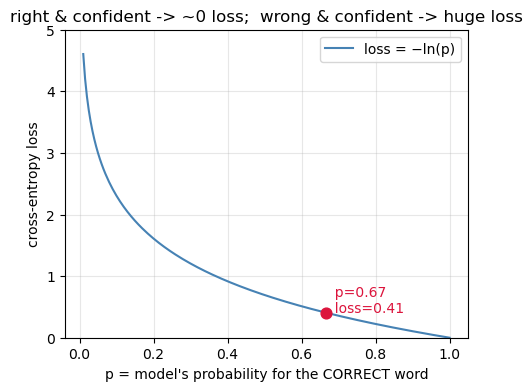

interactive(children=(FloatSlider(value=0.665, description='p(correct)', max=1.0, min=0.01, step=0.01), Output…

In [8]:
import numpy as np, matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def show_crossentropy(p=0.665):
    ps = np.linspace(0.01, 1.0, 200)
    loss = -np.log(p)
    fig, ax = plt.subplots(figsize=(5.2, 4))
    ax.plot(ps, -np.log(ps), color="steelblue", label="loss = −ln(p)")
    ax.scatter([p], [loss], color="crimson", zorder=3, s=60)
    ax.annotate(f"  p={p:.2f}\n  loss={loss:.2f}", (p, loss), fontsize=10, color="crimson")
    ax.set_xlabel("p = model's probability for the CORRECT word"); ax.set_ylabel("cross-entropy loss")
    ax.set_ylim(0, 5); ax.grid(alpha=.3); ax.legend()
    ax.set_title("right & confident -> ~0 loss;  wrong & confident -> huge loss")
    plt.show()

show_crossentropy()                                         # static picture (always visible)
interact(show_crossentropy,                                 # ▶ live slider (drag it in your IDE)
         p=FloatSlider(min=0.01, max=1.0, step=0.01, value=0.665, description="p(correct)"));

## B6 — KL divergence: the extra cost of being wrong

Imagine packing a suitcase using last year's weather forecast for a city whose climate has shifted.
You'll still get there — but you'll carry the wrong clothes and pay for it. **KL divergence** measures
exactly that penalty: the *extra* cost of acting on a belief `q` when reality is really `p`. The mind
meets it again when we fine-tune a model and want to keep it from drifting too far from who it was.

**KL divergence** `D(p ‖ q)` is how many extra nats you pay by using the wrong distribution `q`
when the truth is `p`. It equals cross-entropy minus the true entropy:
```
D(p ‖ q) = H(p, q) − H(p) = Σ pᵢ · ln(pᵢ / qᵢ)
```
It is `0` only when `q = p`, and always `≥ 0`. You will meet it directly in **DPO and RLHF** (P24),
where we keep a fine-tuned model from drifting too far from the original by penalising the KL
between them.

**Worked example by hand.** `p = [0.5, 0.5]`, `q = [0.9, 0.1]`:
```
D = 0.5·ln(0.5/0.9) + 0.5·ln(0.5/0.1)
  = 0.5·ln(0.556)   + 0.5·ln(5.0)
  = 0.5·(−0.588)    + 0.5·(1.609)
  = −0.294 + 0.805 = 0.511 nats
```

In [9]:
import numpy as np
def kl(p, q):
    p, q = np.array(p, float), np.array(q, float)
    return np.sum([pi*np.log(pi/qi) for pi, qi in zip(p, q) if pi > 0])

print("D([0.5,0.5] || [0.9,0.1]) =", round(kl([0.5,0.5],[0.9,0.1]), 3), " (hand 0.511)")
print("D(p || p)                 =", round(kl([0.5,0.5],[0.5,0.5]), 3), " (0 — identical distributions)")
print("\ncheck the identity  D = H(p,q) - H(p):")
p, q = [0.5,0.5], [0.9,0.1]
Hpq = -np.sum([pi*np.log(qi) for pi,qi in zip(p,q)])
Hp  = -np.sum([pi*np.log(pi) for pi in p])
print("  H(p,q) - H(p) =", round(Hpq - Hp, 3), " (same as KL above)")

D([0.5,0.5] || [0.9,0.1]) = 0.511  (hand 0.511)
D(p || p)                 = 0.0  (0 — identical distributions)

check the identity  D = H(p,q) - H(p):
  H(p,q) - H(p) = 0.511  (same as KL above)


## Recap — uncertainty, quantified

| Idea | Formula | Where it appears |
|------|---------|------------------|
| Distribution | `pᵢ ≥ 0`, `Σpᵢ = 1` | every softmax output |
| Expectation | `E[X] = Σ pᵢxᵢ` | averaging loss; RLHF reward |
| Variance | `Σ pᵢ(xᵢ−E)²` | spread, initialisation, normalisation |
| Bayes' rule | `P(A|B)=P(B|A)P(A)/P(B)` | Naive Bayes; updating belief |
| Entropy | `−Σ pᵢ ln pᵢ` | uncertainty of a distribution |
| **Cross-entropy** | `−Σ pᵢ ln qᵢ` → `−ln q_correct` | **the LLM training loss** |
| KL divergence | `Σ pᵢ ln(pᵢ/qᵢ)` | DPO / RLHF drift penalty |

## Common mistakes
1. **Probabilities that don't sum to 1.** Always check; softmax guarantees it, hand-built ones may not.
2. **Ignoring the prior in Bayes.** A rare event stays rare even after positive evidence — that's the whole medical-test lesson.
3. **`ln(0)`.** It's `−∞`. By convention `0·ln0 = 0` (an outcome with zero probability contributes nothing to entropy).
4. **Feeding probabilities to PyTorch's `cross_entropy`.** It expects **logits** and softmaxes internally — don't softmax twice.
5. **Confusing entropy `H(p)` with cross-entropy `H(p,q)`.** Entropy uses one distribution; cross-entropy compares two.

## Exercises (do them in new code cells)
1. Is `[0.2, 0.2, 0.5]` a valid distribution? Fix it so it sums to 1.
2. For `x=[0,10]` with `p=[0.8,0.2]`, compute `E[X]` and `Var[X]` by hand, then verify.
3. Redo the medical-test Bayes calculation with a disease prevalence of 10%. How does `P(sick|+)` change, and why?
4. Compute `H([0.25, 0.25, 0.25, 0.25])` by hand (hint: it's `ln 4`). Verify.
5. A model predicts `[0.1, 0.7, 0.2]` and the true class is index 1. What is the cross-entropy loss? Check with `F.cross_entropy` (remember: it needs logits, so compare using `np.log` on the probs instead).

---

**The mind now senses (P01), strives (P02), and reasons about doubt (P03).** It has every
mathematical instinct it needs — but it has never actually *eaten*. A mind learns nothing without
experience, and its experience comes as **data**. Next, in
[P04 — Data Wrangling & Visualisation](P04_Data_and_Visualization.ipynb), we serve the mind its
first meal: how to load, clean, and *look hard at* the data before we ever ask it to learn.